In [23]:
import numpy as np
from skimage.measure import regionprops
from model_ranking.utils import load_h5
from collections.abc import Iterable

from typing import Any, List
from numpy.typing import NDArray

In [10]:
def calculate_extents(lbl, func=np.median):
    """Aggregate bounding box sizes of objects in label images."""
    if (isinstance(lbl, np.ndarray) and lbl.ndim == 4) or (
        not isinstance(lbl, np.ndarray) and isinstance(lbl, Iterable)
    ):
        return func(
            np.stack([calculate_extents(_lbl, func) for _lbl in lbl], axis=0), axis=0
        )

    n = lbl.ndim
    assert n in (2, 3), ValueError("label image should be 2- or 3-dimensional")

    regs = regionprops(lbl)
    if len(regs) == 0:
        return np.zeros(n)
    else:
        extents = np.array([np.array(r.bbox[n:]) - np.array(r.bbox[:n]) for r in regs])
        if func is None:
            return extents
        else:
            return func(extents, axis=0)

# FlyWing

In [3]:
FW_path = "/scratch/talks/data/FlyWing/GT/test/per03.h5"
fw_labels = load_h5(FW_path, "/volumes/labels/cells")

In [18]:
object_sizes = []
for i in range(len(fw_labels)):
    object_sizes.append(calculate_extents(fw_labels[i].squeeze().astype(np.uint16),func=None))
objects = np.concatenate(object_sizes, axis=0)

In [19]:
objects.shape

(46147, 2)

In [20]:
print(np.median(objects, axis=0), np.std(objects, axis=0))
print(np.min(objects, axis=0), np.max(objects, axis=0))
print(np.mean(objects, axis=0))

[40. 36.] [15.31966147 13.56666354]
[7 6] [106  90]
[42.28914122 38.77240124]


### Sample n object

In [21]:
# Sample n objects from the objects array and print mean object size
n = 50
sampled_indices = np.random.choice(objects.shape[0], n, replace=False)
sampled_objects = objects[sampled_indices]

print(f"Sampled {n} objects")
print(f"Mean object size: {np.mean(sampled_objects, axis=0)}")

Sampled 50 objects
Mean object size: [41.12 40.18]


### median per image

In [6]:
object_sizes = np.zeros((len(fw_labels), 2))
for i in range(len(fw_labels)):
    object_sizes[i] = calculate_extents(fw_labels[i].squeeze().astype(np.uint16))

In [9]:
object_sizes.shape

(160, 2)

In [12]:
print(np.median(object_sizes, axis=0), np.std(object_sizes, axis=0))
print(np.min(object_sizes, axis=0), np.max(object_sizes, axis=0))
print(np.mean(object_sizes, axis=0))

[40. 36.] [1.28062485 0.5580991 ]
[38. 35.] [44. 38.]
[40.525    36.390625]


# Ovules

In [22]:
Ov_path = "/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5"
Ov_labels = load_h5(Ov_path, "label")

In [26]:
object_sizes: List[NDArray[Any]] = []
for i in range(len(Ov_labels)):
    objects_per_slice = calculate_extents(Ov_labels[i].squeeze().astype(np.uint16),func=None)
    if objects_per_slice.ndim == 2:
        object_sizes.append(objects_per_slice)
objects = np.concatenate(object_sizes, axis=0)
print(objects.shape)

(105798, 2)


In [27]:
print(np.median(objects, axis=0), np.std(objects, axis=0))
print(np.min(objects, axis=0), np.max(objects, axis=0))
print(np.mean(objects, axis=0))

[32. 31.] [16.53598934 15.12927777]
[1 1] [115 135]
[31.56479329 30.01817615]


### sample n objects

In [29]:
# Sample n objects from the objects array and print mean object size
n = 50
sampled_indices = np.random.choice(objects.shape[0], n, replace=False)
sampled_objects = objects[sampled_indices]

print(f"Sampled {n} objects")
print(f"Mean object size: {np.mean(sampled_objects, axis=0)}")

Sampled 50 objects
Mean object size: [31.6 28. ]


### Median per image

In [14]:
object_sizes = np.zeros((len(Ov_labels), 2))
for i in range(len(Ov_labels)):
    object_sizes[i] = calculate_extents(Ov_labels[i].squeeze().astype(np.uint16))

In [15]:
print(np.median(object_sizes, axis=0), np.std(object_sizes, axis=0))
print(np.min(object_sizes, axis=0), np.max(object_sizes, axis=0))
print(np.mean(object_sizes, axis=0))

[31. 31.] [3.7440679  3.46955192]
[0. 0.] [42.  37.5]
[30.6765625 30.3453125]


# PNAS

In [31]:
p_path = "/scratch/talks/data/PNAS/test/24hrs_plant18_trim-acylYFP.h5"
p_labels = load_h5(p_path, "label")
p_labels[p_labels == 1] = 0

In [32]:
object_sizes: List[NDArray[Any]] = []
for i in range(len(p_labels)):
    objects_per_slice = calculate_extents(p_labels[i].squeeze().astype(np.uint16),func=None)
    if objects_per_slice.ndim == 2:
        object_sizes.append(objects_per_slice)
objects = np.concatenate(object_sizes, axis=0)
print(objects.shape)

(34633, 2)


In [33]:
print(np.median(objects, axis=0), np.std(objects, axis=0))
print(np.min(objects, axis=0), np.max(objects, axis=0))
print(np.mean(objects, axis=0))

[25. 26.] [9.749659   9.98102528]
[1 1] [52 62]
[24.44238154 24.6904975 ]


### sample n objects

In [38]:
# Sample n objects from the objects array and print mean object size
n = 50
sampled_indices = np.random.choice(objects.shape[0], n, replace=False)
sampled_objects = objects[sampled_indices]

print(f"Sampled {n} objects")
print(f"Mean object size: {np.mean(sampled_objects, axis=0)}")

Sampled 50 objects
Mean object size: [24.5  24.02]


### median per slice

In [26]:
object_sizes = np.zeros((len(p_labels), 2))
for i in range(len(p_labels)):
    object_sizes[i] = calculate_extents(p_labels[i].squeeze().astype(np.uint16))

In [27]:
print(np.median(object_sizes, axis=0), np.std(object_sizes, axis=0))
print(np.min(object_sizes, axis=0), np.max(object_sizes, axis=0))
print(np.mean(object_sizes, axis=0))

[25. 26.] [5.25353454 5.26662681]
[0. 0.] [29.5 29. ]
[24.38218391 24.80747126]


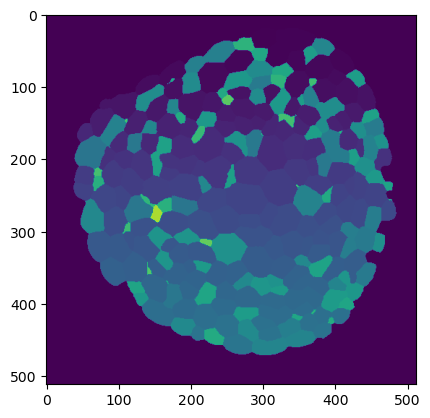

In [24]:
import matplotlib.pyplot as plt
plt.imshow(p_labels[0].squeeze())
plt.show()